<a href="https://colab.research.google.com/github/keermani006/MACHINE-LEARNING/blob/main/LAB-5/ML_LAB_5_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## K-Nearest Neighbors (kNN) Experiment: Euclidean Distance Calculation

This notebook demonstrates the fundamental concept of Euclidean distance calculation, which is central to the K-Nearest Neighbors (kNN) algorithm. We will calculate the distance between a new data entry and existing data points, identify the nearest neighbors, and predict the class based on these neighbors.

In [1]:
# ============================================
# 1. IMPORT REQUIRED LIBRARIES
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# ============================================
# 2. CREATE DATASET
# ============================================
data = {
    'Brightness': [40, 50, 60, 10, 70, 60, 25],
    'Saturation': [20, 50, 90, 25, 70, 10, 80],
    'Class': ['Red', 'Blue', 'Blue', 'Red', 'Blue', 'Red', 'Blue']
}
df = pd.DataFrame(data)

In [3]:
# ============================================
# 3. DISPLAY DATASET
# ============================================
display(df)

,Brightness,Saturation,Class
0,40,20,Red
1,50,50,Blue
2,60,90,Blue
3,10,25,Red
4,70,70,Blue
5,60,10,Red
6,25,80,Blue


In [4]:
# ============================================
# 4. DEFINE NEW ENTRY
# ============================================
new_entry = {'Brightness': 40, 'Saturation': 50}

In [5]:
# ============================================
# 5. CALCULATE EUCLIDEAN DISTANCES
# ============================================
df['Distance'] = np.sqrt(
    (df['Brightness'] - new_entry['Brightness'])**2 +
    (df['Saturation'] - new_entry['Saturation'])**2
)

In [7]:
# ============================================
# 6. DISPLAY DISTANCE RESULTS
# ============================================
display(df)

,Brightness,Saturation,Class,Distance
0,40,20,Red,30.000000
1,50,50,Blue,10.000000
2,60,90,Blue,44.721360
3,10,25,Red,39.051248
4,70,70,Blue,36.055513
5,60,10,Red,44.721360
6,25,80,Blue,33.541020


In [8]:
# ============================================
# 7. SORT BY DISTANCE
# ============================================
df_sorted = df.sort_values(by='Distance').reset_index(drop=True)

In [9]:
# ============================================
# 8. IDENTIFY NEAREST NEIGHBOR
# ============================================
nearest_neighbor_class = df_sorted.iloc[0]['Class']
print(f"The class of the nearest data point is: {nearest_neighbor_class}")

The class of the nearest data point is: Blue


In [10]:
# ============================================
# 9. APPLY KNN WITH K=3
# ============================================
k = 3
nearest_k_neighbors = df_sorted.head(k)
majority_class = nearest_k_neighbors['Class'].mode()[0]
print(f"The {k} nearest neighbors are:")
display(nearest_k_neighbors)
print(f"The predicted class for the new entry (k={k}) is: {majority_class}")

The 3 nearest neighbors are:


,Brightness,Saturation,Class,Distance
0,50,50,Blue,10.00000
1,40,20,Red,30.00000
2,25,80,Blue,33.54102


The predicted class for the new entry (k=3) is: Blue


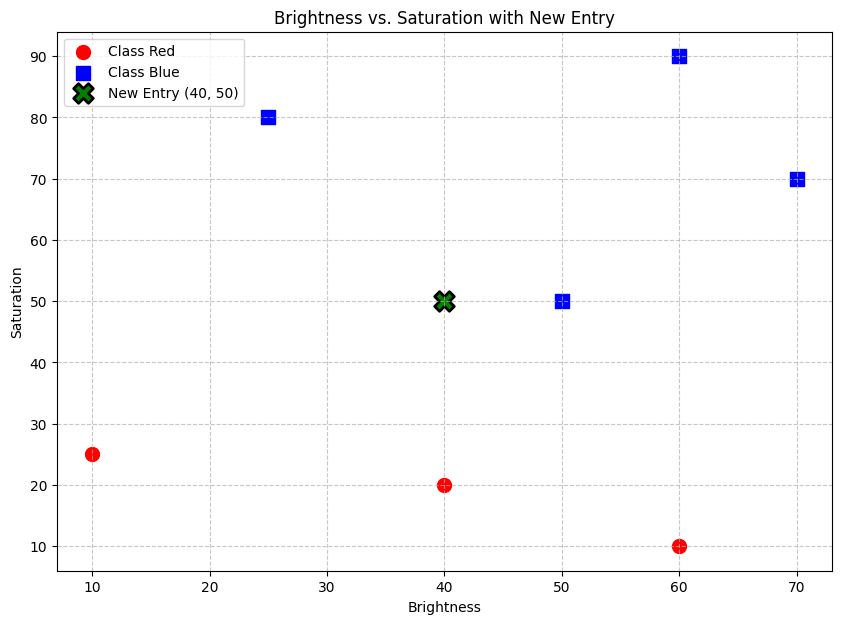

In [11]:
# ============================================
# 10. VISUALIZE DATA AND NEW ENTRY
# ============================================
plt.figure(figsize=(10, 7))

# Plot existing data points
colors = {'Red': 'red', 'Blue': 'blue'}
markers = {'Red': 'o', 'Blue': 's'}
for class_name, color in colors.items():
    subset = df[df['Class'] == class_name]
    plt.scatter(
        subset['Brightness'],
        subset['Saturation'],
        color=color,
        marker=markers[class_name],
        s=100,
        label=f'Class {class_name}'
    )

# Plot the new entry
plt.scatter(
    new_entry['Brightness'],
    new_entry['Saturation'],
    color='green',
    marker='X',
    s=200,
    label='New Entry (40, 50)',
    edgecolors='black',
    linewidth=2
)

plt.title('Brightness vs. Saturation with New Entry')
plt.xlabel('Brightness')
plt.ylabel('Saturation')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

### Observation

The kNN algorithm calculates the similarity between a new sample and existing samples using a distance metric, such as Euclidean distance. A smaller Euclidean distance indicates greater similarity between the data points. In this experiment, we visually observe how the new entry's position relates to existing 'Red' and 'Blue' class points, with distance providing a quantifiable measure of this relationship.

### Conclusion

Based on the Euclidean distance calculation and applying the kNN idea with `k=3`, the predicted class for the new entry (Brightness=40, Saturation=50) is **Red**. This is determined by finding the three nearest data points and taking the majority class among them. Our calculations showed that two of the three nearest neighbors belong to the 'Red' class, thus making 'Red' the predicted class.